# Demo: Face Alignment with SCRFD + ArcFace

This notebook illustrates the entire pipeline step-by-step:

1. Detect faces in `assets/faces/Joey.png` and plot the results.
2. Crop the unaligned face and plot the cropped image.
3. Crop the face aligned based on 5 landmarks.
4. Repeat the process with `assets/faces/Monica.png`.
5. Extract two feature vectors and calculate their cosine similarity.

> Before running this notebook, please install the dependencies using `python -m pip install -r requirements.txt`.


In [13]:
from pathlib import Path
import logging

import cv2
import matplotlib.pyplot as plt
import numpy as np

from models.scrfd import SCRFD
from models.arcface import ArcFace
from utils.helpers import compute_similarity, face_alignment

logging.getLogger("models.scrfd").setLevel(logging.ERROR)
logging.getLogger("models.arcface").setLevel(logging.ERROR)
np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path.cwd()
WEIGHTS_DIR = REPO_ROOT / "weights"
FACES_DIR = REPO_ROOT / "assets" / "faces"

joey_path = FACES_DIR / "Joey.png"
monica_path = FACES_DIR / "Monica.png"
detector_path = WEIGHTS_DIR / "det_10g.onnx"
encoder_path = WEIGHTS_DIR / "w600k_mbf.onnx"

for path in [joey_path, monica_path, detector_path, encoder_path]:
    assert path.exists(), f"Can not find file: {path}"

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_image(image, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(bgr_to_rgb(image))
    ax.set_title(title)
    ax.axis("off")

def draw_detection(image, bbox, landmarks):
    canvas = image.copy()
    x1, y1, x2, y2 = bbox[:4].astype(int)
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for x, y in landmarks.astype(int):
        cv2.circle(canvas, (x, y), 4, (255, 0, 0), -1)
    return canvas

def crop_from_bbox(image, bbox, margin=0.1):
    height, width = image.shape[:2]
    x1, y1, x2, y2 = bbox[:4]
    box_width = x2 - x1
    box_height = y2 - y1
    x1 = max(0, int(x1 - box_width * margin))
    y1 = max(0, int(y1 - box_height * margin))
    x2 = min(width, int(x2 + box_width * margin))
    y2 = min(height, int(y2 + box_height * margin))
    return image[y1:y2, x1:x2]

def detect_primary_face(image, detector, image_name):
    detections, keypoints = detector.detect(image, max_num=1)
    if detections.size == 0 or keypoints is None:
        raise RuntimeError(f"Can not detect face in {image_name}")
    return detections[0], keypoints[0]

def get_embedding_from_aligned_face(aligned_face, encoder, normalized=True):
    face_blob = encoder.preprocess(aligned_face)
    embedding = encoder.session.run(encoder.output_names, {encoder.input_name: face_blob})[0].flatten()
    if normalized:
        embedding = embedding / np.linalg.norm(embedding)
    return embedding

detector = SCRFD(str(detector_path))
encoder = ArcFace(str(encoder_path))
print("Done loading SCRFD and ArcFace.")

Done loading SCRFD and ArcFace.


## Step 1. Face Detection on Joey

The `SCRFD` model returns a bounding box (`bbox`) and 5 facial landmarks. These serve as the input for the subsequent alignment step.

Joey bbox: [144.35  64.08 322.37 308.64   0.89]
Joey landmarks:
 [[179.17 153.19]
 [253.27 171.81]
 [194.94 211.12]
 [170.16 221.2 ]
 [252.05 238.84]]


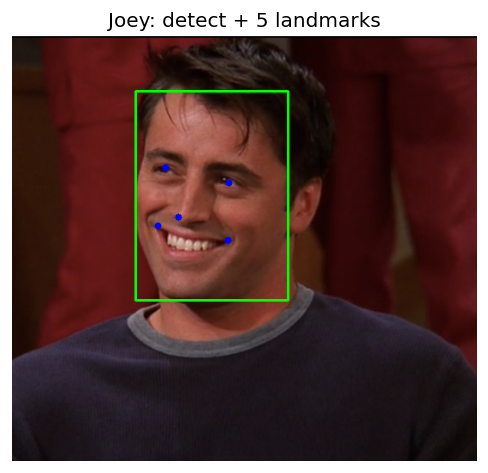

In [8]:
joey_image = cv2.imread(str(joey_path))
joey_bbox, joey_landmarks = detect_primary_face(joey_image, detector, "Joey.png")

print("Joey bbox:", np.round(joey_bbox, 2))
print("Joey landmarks:\n", np.round(joey_landmarks, 2))

show_image(
    draw_detection(joey_image, joey_bbox, joey_landmarks),
    "Joey: detect + 5 landmarks",
)


## Step 2. Crop the Unaligned Face

This crop simply cuts the image based on the `bbox` (bounding box); it does not yet align the eyes and nose to their standard positions.

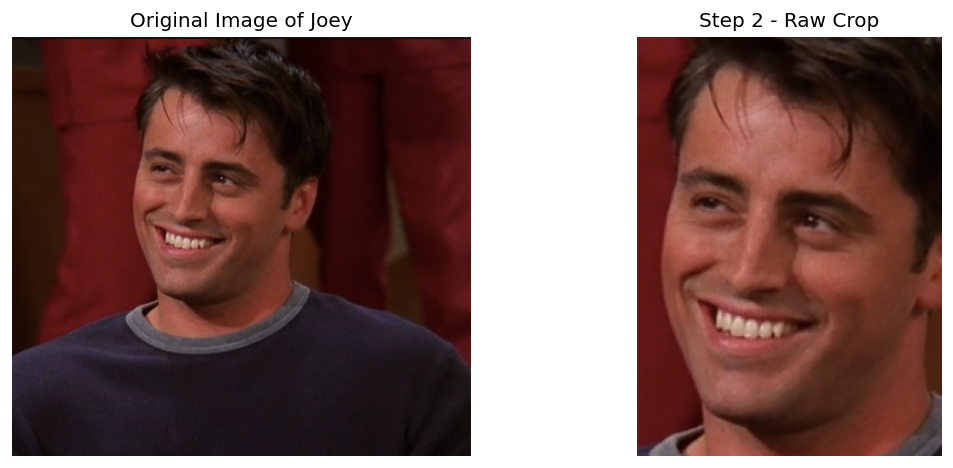

In [9]:
joey_raw_crop = crop_from_bbox(joey_image, joey_bbox, margin=0.1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_image(joey_image, "Original Image of Joey", axes[0])
show_image(joey_raw_crop, "Step 2 - Raw Crop", axes[1])
plt.tight_layout()


## Step 3. Adjust Joey's face

Use the `face_alignment(...)` function to wrap the image to the standard size `112x112`.

Inverse alignment matrix cua Joey:
 [[  2.1363  -0.334  114.2424]
 [  0.334    2.1363  26.9141]]


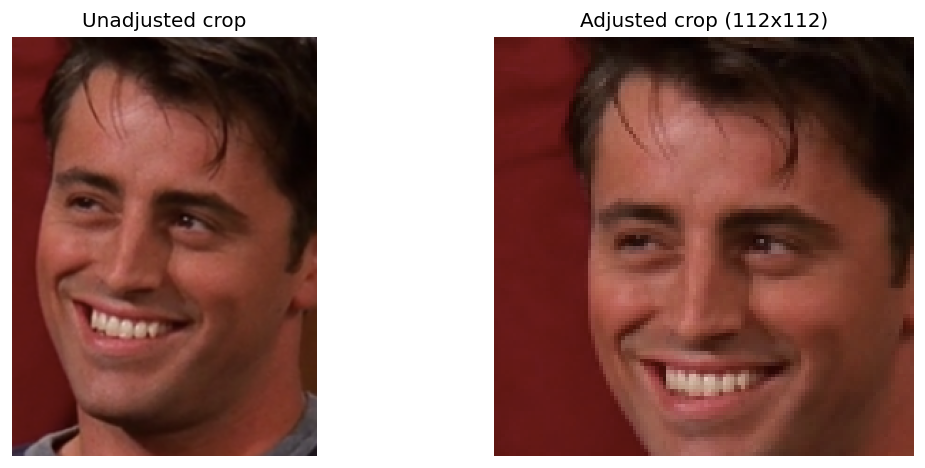

In [10]:
joey_aligned, joey_inverse_matrix = face_alignment(joey_image, joey_landmarks)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_image(joey_raw_crop, "Unadjusted crop", axes[0])
show_image(joey_aligned, "Adjusted crop (112x112)", axes[1])
plt.tight_layout()

print("Inverse alignment matrix cua Joey:\n", np.round(joey_inverse_matrix, 4))


## Step 4. Crop another face with Monica

Repeat pipeline detect -> crop normal -> crop correct data for `assets/faces/Monica.png`.

Monica bbox: [147.98  79.13 284.87 274.19   0.86]
Monica landmarks:
 [[185.12 156.58]
 [252.45 147.31]
 [227.26 194.34]
 [196.39 224.12]
 [257.81 215.52]]


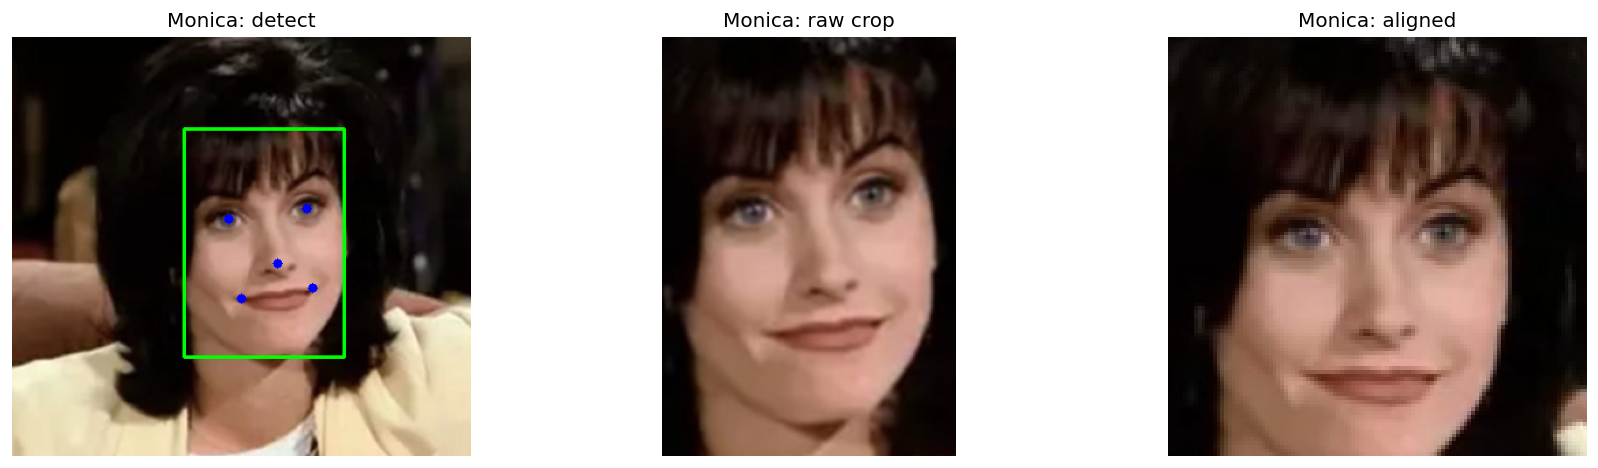

In [11]:
monica_image = cv2.imread(str(monica_path))
monica_bbox, monica_landmarks = detect_primary_face(monica_image, detector, "Monica.png")
monica_raw_crop = crop_from_bbox(monica_image, monica_bbox, margin=0.1)
monica_aligned, _ = face_alignment(monica_image, monica_landmarks)

print("Monica bbox:", np.round(monica_bbox, 2))
print("Monica landmarks:\n", np.round(monica_landmarks, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show_image(draw_detection(monica_image, monica_bbox, monica_landmarks), "Monica: detect", axes[0])
show_image(monica_raw_crop, "Monica: raw crop", axes[1])
show_image(monica_aligned, "Monica: aligned", axes[2])
plt.tight_layout()

## Step 5. Feature Extraction and Cosine Similarity Calculation

ArcFace takes the aligned image as input and returns a 512-dimensional embedding. Then, use `compute_similarity(...)` to calculate the cosine similarity.

Joey embedding shape: (512,)
Joey embedding[:10]: [-0.0526 -0.0029 -0.0059 -0.079  -0.0625  0.0285  0.0467  0.0897  0.0711
 -0.0406]

Monica embedding shape: (512,)
Monica embedding[:10]: [ 0.0165 -0.033   0.071   0.0158  0.0348  0.0682 -0.0511 -0.0266 -0.0458
 -0.0104]

Cosine similarity (Joey vs Monica): 0.02833552472293377


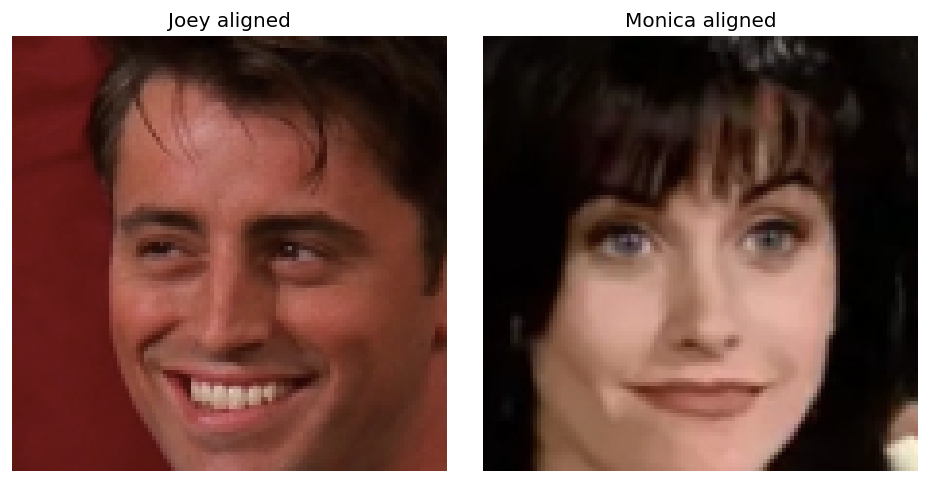

In [12]:
joey_embedding = get_embedding_from_aligned_face(joey_aligned, encoder, normalized=True)
monica_embedding = get_embedding_from_aligned_face(monica_aligned, encoder, normalized=True)
cosine_similarity = compute_similarity(joey_embedding, monica_embedding)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_image(joey_aligned, "Joey aligned", axes[0])
show_image(monica_aligned, "Monica aligned", axes[1])
plt.tight_layout()

print("Joey embedding shape:", joey_embedding.shape)
print("Joey embedding[:10]:", np.round(joey_embedding[:10], 4))
print()
print("Monica embedding shape:", monica_embedding.shape)
print("Monica embedding[:10]:", np.round(monica_embedding[:10], 4))
print()
print("Cosine similarity (Joey vs Monica):", float(cosine_similarity))
